# Segmentação de Imagens com CLIPSeg

Este notebook utiliza o modelo `CIDAS/clipseg-rd64-refined` para realizar segmentação de imagens baseada em texto (prompts).

In [ ]:
# Instalação de dependências adicionais caso necessário
# %pip install transformers torch torchvision pillow matplotlib

In [1]:
from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation
from PIL import Image
import torch
import matplotlib.pyplot as plt
import os

# Carregar o modelo e o processador
processor = CLIPSegProcessor.from_pretrained("CIDAS/clipseg-rd64-refined")
model = CLIPSegForImageSegmentation.from_pretrained("CIDAS/clipseg-rd64-refined")

preprocessor_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

c:\Users\Murilo\Documents\arquivos_programacao\NLW\projeto 2\.venv\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Murilo\.cache\huggingface\hub\models--CIDAS--clipseg-rd64-refined. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
The image processor of type `ViTImageProcessor` is now loaded as a fast pr

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/974 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/603M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/462 [00:00<?, ?it/s]

CLIPSegForImageSegmentation LOAD REPORT from: CIDAS/clipseg-rd64-refined
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
clip.text_model.embeddings.position_ids   | UNEXPECTED |  | 
clip.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [3]:
def segment_image(image_path, prompts):
    image = Image.open(image_path).convert("RGB")
    
    # Preparar as entradas
    inputs = processor(text=prompts, images=[image] * len(prompts), padding="max_length", return_tensors="pt")
    
    # Inferência
    with torch.no_grad():
        outputs = model(**inputs)
    
    # O modelo retorna logits de tamanho [batch_size, 352, 352]
    preds = outputs.logits
    if len(prompts) == 1:
        preds = preds.unsqueeze(0)
        
    return image, preds

In [4]:
def visualize_results(image, preds, prompts):
    n_prompts = len(prompts)
    fig, ax = plt.subplots(1, n_prompts + 1, figsize=((n_prompts + 1) * 5, 5))
    
    ax[0].imshow(image)
    ax[0].set_title("Original")
    ax[0].axis("off")
    
    for i, prompt in enumerate(prompts):
        # Redimensionar a máscara para o tamanho original da imagem
        mask = torch.sigmoid(preds[i])
        ax[i+1].imshow(mask)
        ax[i+1].set_title(f"Prompt: {prompt}")
        ax[i+1].axis("off")
    
    plt.tight_layout()
    plt.show()

Processando: bird.jpeg


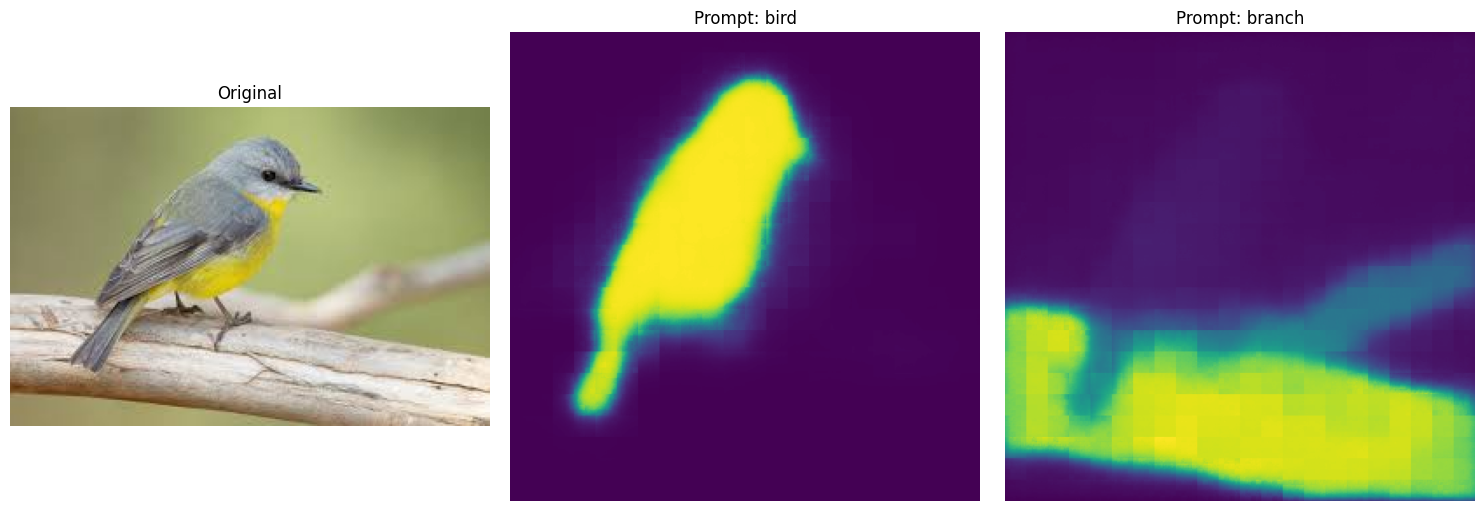

Processando: kitchen.jpeg


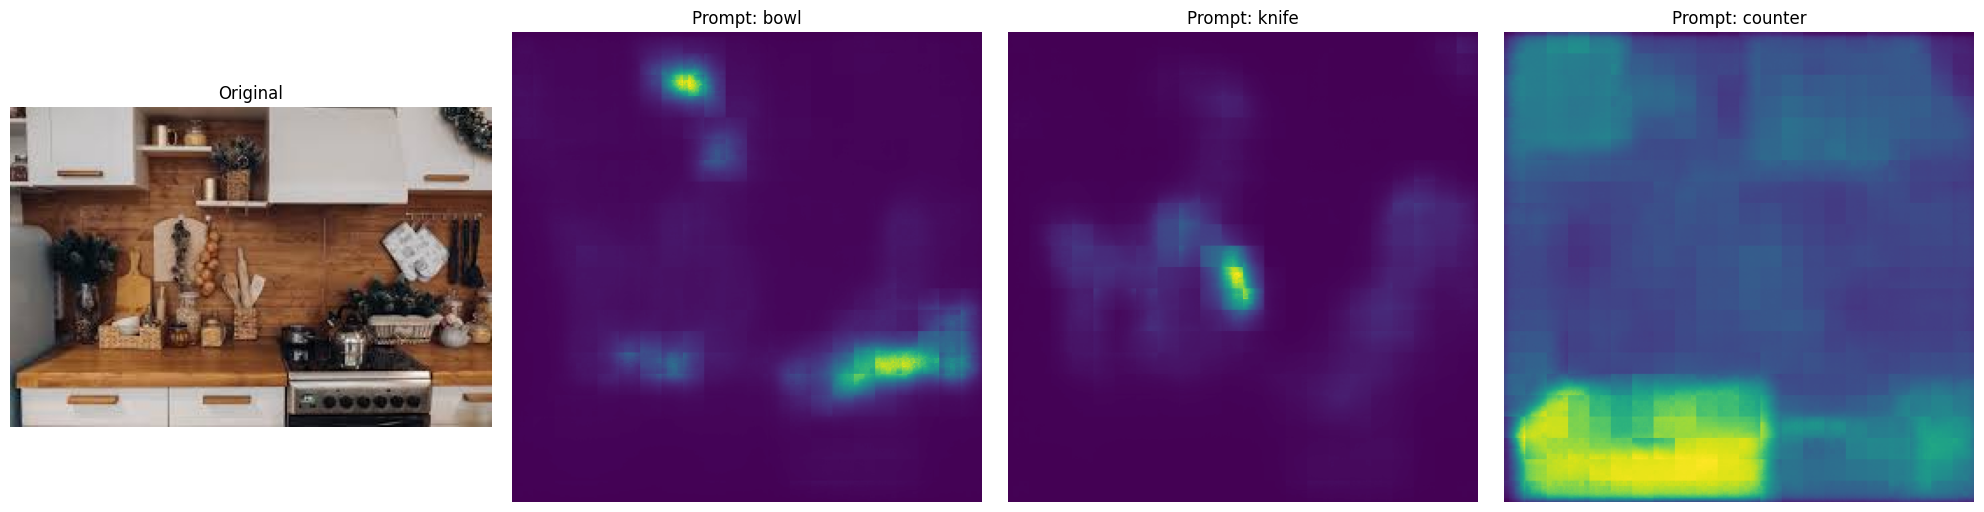

Processando: pizza.jpeg


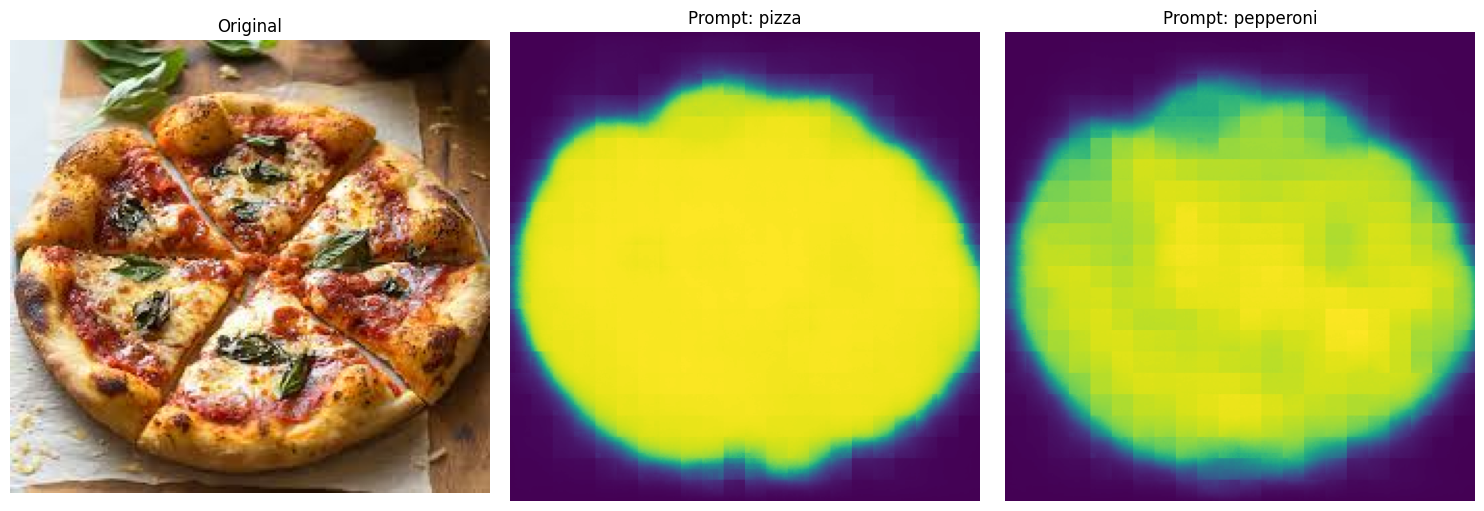

In [5]:
# Configurações
image_dir = "imagens"
image_files = [f for f in os.listdir(image_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

# Dicionário de prompts sugeridos para cada imagem (opcional)
default_prompts = {
    "bird.jpeg": ["bird", "branch"],
    "kitchen.jpeg": ["bowl", "knife", "counter"],
    "pizza.jpeg": ["pizza", "pepperoni"]
}

all_prompts = ["object"]

for filename in image_files:
    path = os.path.join(image_dir, filename)
    print(f"Processando: {filename}")
    
    # Usa prompts específicos se definidos, senão usa o padrão
    prompts = default_prompts.get(filename, all_prompts)
    
    img, predictions = segment_image(path, prompts)
    visualize_results(img, predictions, prompts)